# 04 · P3 묵은재고 개입 시뮬레이션

**목적:** "90일+ 미판매 매물에 가격 인하를 제안하면?"의 (1) 전제 검증, (2) 대상 규모,
(3) 정직한 효과 프레이밍, (4) A/B 설계.

⚠️ **선결 검증:** "동종 중앙값까지 인하"가 통하려면 *같은 동종군에서 싼 매물이 더 팔려야*
한다. 이걸 먼저 데이터로 확인한다 — 통하지 않으면 메커니즘을 바꾼다.

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib, matplotlib.pyplot as plt
import sys

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
from analysis import benchmarks as bm

matplotlib.rcParams["font.family"] = "AppleGothic"
matplotlib.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110
FIG = ROOT / "results" / "figures"

df = bm.load()
g = df.groupby(["brand", "category_l1", "condition"])
df["grp_n"] = g["price_final"].transform("size")
df["grp_pct"] = g["price_final"].rank(pct=True)
df["grp_med"] = g["price_final"].transform("median")
ing = df[df["grp_n"] >= 5].copy()   # 동종군 보유(n>=5)
print(f"전체 {len(df):,} | 동종군 보유 {len(ing):,} ({len(ing)/len(df):.1%})")

전체 284,654 | 동종군 보유 258,442 (90.8%)


## 1. 전제 검증 — 동종군 내 '싸게 = 더 팔림'이 성립하나? (결론: 아니오)

가격 백분위 구간별 sell-through가 평평하면, 인하가 판매를 끌어올린다는 근거가 약하다.

동종군 내 가격 백분위별 sell-through(%):
pbin
하위25%(저가)    19.2
25-50        18.6
50-75        18.1
상위25%(고가)    19.9

판매 vs 미판매 평균 동종백분위: 0.519 vs 0.509
→ 거의 평평/동일: '동종군에서 싸다'가 판매를 예측하지 못함 (내생성: 매력적 변형이 비싸도 팔림)


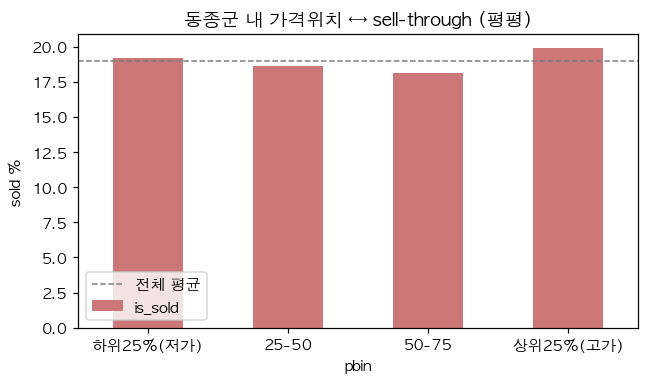

In [2]:
ing["pbin"] = pd.cut(ing["grp_pct"], [0, .25, .5, .75, 1.0],
                     labels=["하위25%(저가)", "25-50", "50-75", "상위25%(고가)"])
st = (ing.groupby("pbin", observed=True)["is_sold"].mean() * 100).round(1)
print("동종군 내 가격 백분위별 sell-through(%):"); print(st.to_string())
print(f"\n판매 vs 미판매 평균 동종백분위: "
      f"{ing[ing.is_sold==1].grp_pct.mean():.3f} vs {ing[ing.is_sold==0].grp_pct.mean():.3f}")
print("→ 거의 평평/동일: '동종군에서 싸다'가 판매를 예측하지 못함 (내생성: 매력적 변형이 비싸도 팔림)")

fig, ax = plt.subplots(figsize=(6, 3.6))
st.plot(kind="bar", ax=ax, rot=0, color="#c77")
ax.axhline(ing["is_sold"].mean()*100, ls="--", c="gray", lw=1, label="전체 평균")
ax.set(title="동종군 내 가격위치 ↔ sell-through (평평)", ylabel="sold %"); ax.legend()
fig.tight_layout(); fig.savefig(FIG / "p3_price_flat.png", bbox_inches="tight"); plt.show()

## 2. 묵은재고 규모 + 두 가지 개입 대상 (과가 / 찜보유)

가격위치가 판매를 예측 못 하므로, 개입을 두 갈래로 분리:
**(A) 가격 = 효과 미지 → 실험 arm**, **(B) 찜 보유 = 드러난 수요 → 오퍼 arm**.

In [3]:
heart_med = df["like_count"].median()
rows = []
for thr in [60, 90]:
    aged_all = df[(df.is_sold == 0) & (df.age_days >= thr)]
    aged = ing[(ing.is_sold == 0) & (ing.age_days >= thr)].copy()
    over50 = (aged["price_final"] > aged["grp_med"]).mean()
    over75 = (aged["grp_pct"] > 0.75).mean()
    ov = aged[aged["price_final"] > aged["grp_med"]]
    cut_med = ((ov["price_final"] - ov["grp_med"]) / ov["price_final"] * 100).median()
    has_heart = (aged_all["like_count"] > 0).mean()
    many_heart = (aged_all["like_count"] >= heart_med).mean()
    rows.append({"threshold_days": thr, "aged_unsold_total": int(len(aged_all)),
                 "aged_in_group": int(len(aged)),
                 "over_median_pct": round(over50, 3), "over_p75_pct": round(over75, 3),
                 "markdown_to_median_pct_median": round(float(cut_med), 1),
                 "has_heart_pct": round(has_heart, 3), "ge_median_heart_pct": round(many_heart, 3)})
    print(f"[{thr}일+ 미판매] 총 {len(aged_all):,} / 동종군 {len(aged):,}")
    print(f"   (A 가격arm) 중앙값초과 {over50:.0%}, 상위25% {over75:.0%}, "
          f"중앙값까지 인하폭 중앙값 {cut_med:.0f}%")
    print(f"   (B 오퍼arm) 찜>0 {has_heart:.0%}, 찜>=중앙값({heart_med:.0f}) {many_heart:.0%}\n")
sizing = pd.DataFrame(rows)

[60일+ 미판매] 총 146,121 / 동종군 135,686
   (A 가격arm) 중앙값초과 50%, 상위25% 27%, 중앙값까지 인하폭 중앙값 38%
   (B 오퍼arm) 찜>0 93%, 찜>=중앙값(6) 59%

[90일+ 미판매] 총 123,311 / 동종군 113,897
   (A 가격arm) 중앙값초과 49%, 상위25% 27%, 중앙값까지 인하폭 중앙값 38%
   (B 오퍼arm) 찜>0 93%, 찜>=중앙값(6) 59%



## 3. 진단단계 교차 — '충분히 보였는데 미판매'(stageB)가 가격/오퍼의 본 타깃

(P5 엔진 재사용) 저노출(stageA)은 매칭(P4) 영역, 충분노출(stageB)이 가격/오퍼 영역.

90일+ 미판매 진단 분포:
stage
B.충분노출+미판매(→가격/오퍼)    74.4
A.저노출(→P4매칭)          25.6

stageB 중 찜>0: 98% | 동종 중앙값 초과: 46%


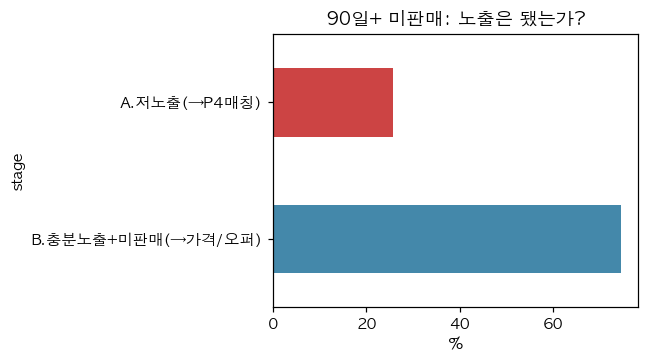

In [4]:
bl = bm.build_view_baselines(df)
b = bl.reset_index().rename(columns={"v25": "v25_"})
aged90 = df[(df.is_sold == 0) & (df.age_days >= 90) & df.price_tier.notna()].merge(
    b[["category_l1", "price_tier", "age_bucket", "v25_"]],
    on=["category_l1", "price_tier", "age_bucket"], how="left")
aged90["stage"] = np.where(aged90["view_count"] < aged90["v25_"], "A.저노출(→P4매칭)",
                           "B.충분노출+미판매(→가격/오퍼)")
stage_share = aged90["stage"].value_counts(normalize=True).round(3)
print("90일+ 미판매 진단 분포:"); print((stage_share*100).round(1).to_string())

stageB = aged90[aged90["stage"].str.startswith("B")]
print(f"\nstageB 중 찜>0: {(stageB['like_count']>0).mean():.0%} "
      f"| 동종 중앙값 초과: {(stageB['price_final']>stageB['grp_med']).mean():.0%}")

fig, ax = plt.subplots(figsize=(6, 3.4))
(stage_share*100).plot(kind="barh", ax=ax, color=["#48a", "#c44"])
ax.set(title="90일+ 미판매: 노출은 됐는가?", xlabel="%")
fig.tight_layout(); fig.savefig(FIG / "p3_stage_split.png", bbox_inches="tight"); plt.show()

## 4. 정직한 효과 프레이밍 + A/B 설계

- **가격위치↔판매가 평평**하므로 "인하 → +X% 판매" 수치를 만들 수 없다(내생성).
  관측상 과가(상위25%) vs 적정(25-50)의 sell-through 차이는 **참고용 하한**일 뿐.
- 따라서 **효과는 A/B로만 확정.** 두 arm 분리:
  - **arm A (가격 실험):** 90일+ stageB 과가 매물에 "동종 중앙값까지 −N%" 제안.
    1차지표=제안 후 30일 전환. ← 인하의 *인과* 탄력성을 처음으로 측정.
  - **arm B (찜 오퍼):** 찜 보유 묵은매물 → 찜한 사람에게 비공개 할인 오퍼.
    드러난 수요 공략, 공개 가격 안 내려도 됨. 1차지표=오퍼 수락→거래.
- 가드레일: 셀러 이탈, 평균 판매가 하락(마진), 인기매물 잠식 없음.

In [5]:
ref_gap = round(float(st["상위25%(고가)"] - st["25-50"]), 1)  # 참고용(내생성 주의)
result = {
    "premise_check": {
        "sellthrough_by_within_group_price_bin": st.to_dict(),
        "sold_vs_unsold_mean_pct": [round(float(ing[ing.is_sold==1].grp_pct.mean()), 3),
                                     round(float(ing[ing.is_sold==0].grp_pct.mean()), 3)],
        "conclusion": "동종군 내 가격위치는 sell-through를 예측하지 못함 → 단순 인하 전제 미지지",
        "ref_overpriced_minus_fair_pp": ref_gap,
    },
    "sizing": sizing.to_dict(orient="records"),
    "stage_split_90d": stage_share.to_dict(),
    "ab_design": {
        "armA_price_experiment": "90일+ stageB 과가 → 동종중앙값까지 인하 제안, 30일 전환 측정",
        "armB_offer_to_wishers": "찜 보유 묵은매물 → 찜한 사람에 비공개 오퍼, 수락→거래 측정",
        "guardrails": ["셀러 이탈", "평균 판매가/마진", "인기매물 노출 잠식"],
    },
}
(ROOT / "results" / "p3_staleness.json").write_text(
    json.dumps(result, ensure_ascii=False, indent=2), encoding="utf-8")
print(json.dumps(result, ensure_ascii=False, indent=2))

{
  "premise_check": {
    "sellthrough_by_within_group_price_bin": {
      "하위25%(저가)": 19.2,
      "25-50": 18.6,
      "50-75": 18.1,
      "상위25%(고가)": 19.9
    },
    "sold_vs_unsold_mean_pct": [
      0.519,
      0.509
    ],
    "conclusion": "동종군 내 가격위치는 sell-through를 예측하지 못함 → 단순 인하 전제 미지지",
    "ref_overpriced_minus_fair_pp": 1.3
  },
  "sizing": [
    {
      "threshold_days": 60,
      "aged_unsold_total": 146121,
      "aged_in_group": 135686,
      "over_median_pct": 0.499,
      "over_p75_pct": 0.27,
      "markdown_to_median_pct_median": 37.5,
      "has_heart_pct": 0.928,
      "ge_median_heart_pct": 0.586
    },
    {
      "threshold_days": 90,
      "aged_unsold_total": 123311,
      "aged_in_group": 113897,
      "over_median_pct": 0.494,
      "over_p75_pct": 0.266,
      "markdown_to_median_pct_median": 37.5,
      "has_heart_pct": 0.93,
      "ge_median_heart_pct": 0.594
    }
  ],
  "stage_split_90d": {
    "B.충분노출+미판매(→가격/오퍼)": 0.744,
    "A.저노출(→P4매칭)": 0.25